  **<big><big>Matemáticas Aplicadas II</big></big><br><small>Departamento de Ciencias Físicas y Aplicadas/ Facultad de Ingeniería, Diseño y Ciencias Aplicadas</small><br><small>**  

- Nathalia Mendoza Peña - A00403414
- Jose Miguel Marín Ramírez - A00394923
- Juan Esteban Eraso Gutiérrez - A00399655
- Nicolas Cardona Restrepo - A00373470







**Enunciado del problema**

 Suponga que un avión mantiene su dirección hacia un aeropuerto en el origen. Si $v_0=500$ $mi/h$ y $w= 50$ $mi/h$ (con el viento soplando hacia el norte), y el avión inicia en el punto $(200, 150)$, pruebe que su trayectoria se describe por:
$$y+\sqrt{x^2+y^2}=2(200x^9)^{\frac{1}{10}}$$

# Implementación numérica:

Utilizar un métodos numérico para resolver la ecuación diferencial que describa el problema. Encontrar la solución que permita representar la posición del avión en un plano dos dimensional mediante una curva $f(x)$.


Vamos a calcular la derivada implícita de la función $y+\sqrt{x^2+y^2}=2(200x^9)^{\frac{1}{10}}$ utilizando sympy. Luego, graficaremos la función para demostrar que su derivada implícita coincide con la trayectoria.

In [ ]:
import sympy as sp
from sympy import Function, dsolve, Derivative, checkodesol

x, y = sp.symbols('x y')
#Ecuacion que nos proporcionan(describe la trayectoria del avion)
ecuacion_trayectoria = sp.Eq(y + sp.sqrt(x**2 + y**2), 2*(200*x**9)**(1/10))

dydx = sp.solve(ecuacion_trayectoria, y)
#Derivada implicita
dydx

[1.47176004663119e-29*(-1.0e+28*x**2 + 1.15415992472577e+29*(x**9)**(1/5))/(x**9)**(1/10)]

<ipython-input-3-10650f6a7a56>:6: RuntimeWarning: invalid value encountered in divide
  return 1.47176004663119e-29 * (-1.0e+28 * x**2 + 1.15415992472577e+29 * (x**9)**(1/5)) / (x**9)**(1/10)


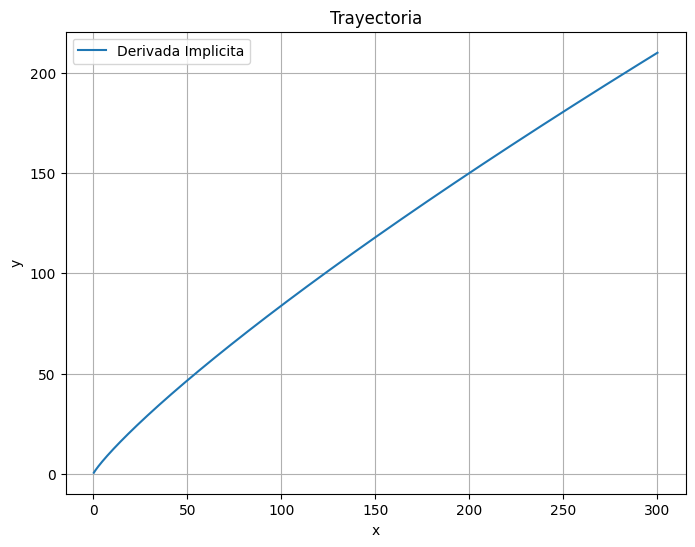

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definir la implicita
def f(x):
    return 1.47176004663119e-29 * (-1.0e+28 * x**2 + 1.15415992472577e+29 * (x**9)**(1/5)) / (x**9)**(1/10)

x_vals = np.linspace(0, 300, 1000)

y_vals = f(x_vals)


plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label='Derivada Implicita')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectoria')
plt.grid(True)
plt.legend()
plt.show()


Ahora usando la ecuacion diferencial que construimos $\frac{y}{x} - \frac{1}{10} ⋅ \sqrt{1+ (\frac{y}{x})^2}$ la resolveremos numéricamente, utilizaremos el método de Euler. Este método nos permitirá aproximar la solución de la ecuación diferencial a lo largo de una trayectoria. Lo que nos permitira representar la posicion del avion.

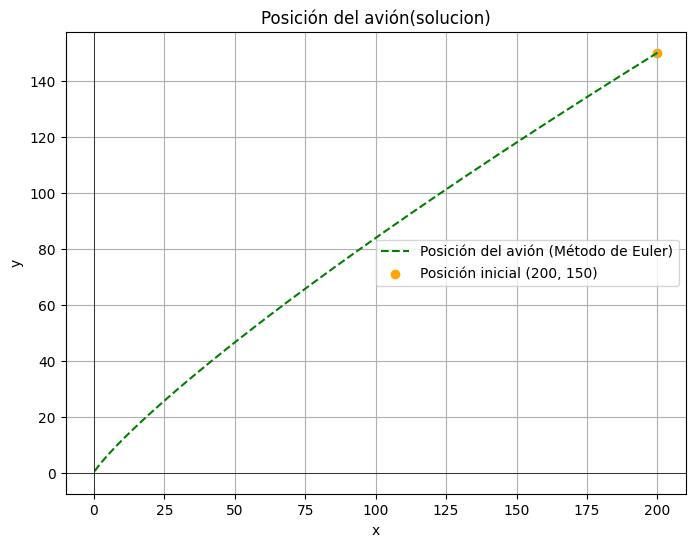

In [ ]:
def euler(f, y0, x0, xmax, n):
    X = np.linspace(x0, xmax, n+1)
    h = (xmax - x0) / n
    Y = np.zeros_like(X)
    Y[0] = y0
    for i in range(n):
        dy_dx = f(X[i], Y[i])
        Y[i+1] = Y[i] + h * dy_dx
    return X, Y

# Ecuacion diferencial
def f(x, y):
    return (y/x)-(1/10)*(np.sqrt(1 + (y/x)**2))

# Parámetros iniciales
x0, y0 = 200, 150
xmax = 0
n = 2000

# Obtener los valores de X e Y mediante el método de Euler
X, Y = euler(f, y0, x0, xmax, n)

# Graficar la posición del avión y la función proporcionada
plt.figure(figsize=(8, 6))
plt.plot(X, Y, label='Posición del avión (Método de Euler)', linestyle='--', color='g')
plt.scatter(x0, y0, color='orange', label='Posición inicial (200, 150)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Posición del avión(solucion)')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True)
plt.show()


# Simulación gráfica:

Utilizar una herramienta de programación (como Python con bibliotecas gráficas o geogebra) para crear una representacion grafica de la trayectoria del avión.

In [ ]:
from IPython.display import IFrame
url_geogebra = "https://www.geogebra.org/calculator/geudhcyq"

width = 800
height = 600


IFrame(url_geogebra, width=width, height=height)

# Sustento téorico del problema.

1. Construya el modelo de movimiento haciendo uso de trigonometria y nociones físicas. Lo anterior le permitira entender y representar el cambio de las componentes de la velocidad en el tiempo.

2. Con el análisis anterior construya la ecuación diferencial que represente el movimiento.

3. Resuelva la ecuación diferencial. Debe entender que la ecuación diferencial es una ecuación homogenea. Para resolver estas ecuaciones debe realizar una sustitución y realizar un cambio de variable. la sustitución que debe hacer es:$$v=\frac{y}{x}$$

Para construir el modelo es necesario entender las componentes del vector velocidad con respecto a la fisica.
##**1**

**1.1.** **Velocidad**:
   - La velocidad se define como la cantidad de espacio recorrido por unidad de tiempo.
   - Se representa como $(v)$.
   - La fórmula general para la velocidad es:
     $$v = \frac{\Delta r}{\Delta t}$$
     Donde:
     - $(v)$ es la magnitud de la velocidad del cuerpo.
     - $(\Delta r)$ es el cambio en la posición del objeto (distancia recorrida).
     - $(\Delta t)$ es el cambio en el tiempo transcurrido.

**1.2** **Componentes de Velocidad**:
   - En situaciones bidimensionales, las velocidades pueden apuntar en direcciones diagonales.
   - Para simplificar los cálculos, descomponemos el vector de velocidad en dos direcciones separadas: **la velocidad horizontal** $(v_x)$ y **la velocidad vertical** $(v_y)$.
   - Cuando un objeto se mueve en un plano, su velocidad total puede descomponerse en dos componentes: una en la dirección del eje $(x)$ **(horizontal)** y otra en la dirección del eje $(y$) **(vertical)**. Si la velocidad total es $(v)$ y el ángulo que forma con el eje $(x)$ es $\theta$, entonces la componente de velocidad en la dirección del eje $x$ $(v_x)$ es $$ \cos \theta = \frac{v_x}{v} $$ y la componente en la dirección del eje $y$ $(v_y)$ es $$ \sin \theta = \frac{v_y}{v} $$

Para el avión que mantiene su dirección hacia el aeropuerto(origen), la componente de velocidad en la dirección del eje $x$ $(v_x)$ es la velocidad horizontal a la que se mueve el avión hacia el aeropuerto, mientras que la componente en la dirección del eje $y$ $(v_y)$ es la velocidad vertical causada por el viento que sopla hacia el norte (representado por $w$).

Dado que $$v_x = v_0 \cdot \cos \theta$$ donde $v_0$ es la velocidad inicial y $\theta$ es el ángulo que forma con el eje $x$, y sabiendo que
$$ \cos \theta = \frac{ca}{h} = \frac{x}{\sqrt{x^2+y^2}} $$
(donde $x$ es la distancia horizontal y $y$ es la distancia vertical), podemos sustituir y obtener:

$$\frac{dx}{dt}=v_x = v_0 \cdot \frac{x}{\sqrt{x^2+y^2}} $$
Esto nos da la relación entre la velocidad horizontal del avión $v_x$ y su velocidad inicial $v_0$ en función de la posición del avión en el plano.

Además, dado que el viento sopla hacia el norte, afecta solo la componente vertical de la velocidad, por lo que restamos la velocidad del viento $w$ a la componente $v_y$ del avión, lo que nos da la velocidad vertical total del avión $v_y$. Es decir:
$$ \frac{v_y}{v_0}  =\sin \theta - w$$
$$v_y = v_0 \cdot\sin  \theta - w$$ y sabiendo que
$$ \sin \theta = \frac{co}{h} = \frac{y}{\sqrt{x^2+y^2}} $$ al sustituir se obtiene:

$$\frac{dy}{dt}=v_y = v_0 \cdot \frac{y}{\sqrt{x^2+y^2}} - w $$
Ahora, aplicando la regla de la cadena para obtener la ecuación diferencial $\frac{dy}{dx}$, seguimos estos pasos:

- Comenzamos con la ecuación diferencial $$\frac{dy}{dx} = \frac{dy}{dt} \cdot \frac{dt}{dx}$$
- Como ya encontramos $$\frac{dy}{dt}$$ y $$\frac{dx}{dt}$$ utilizando las ecuaciones de velocidad $v_x$ y $v_y$.
- Luego, invertimos $$\frac{dx}{dt}$$ para obtener $$\frac{dt}{dx}$$.
- Finalmente, multiplicamos $$\frac{dy}{dt}$$ por $$\frac{1}{\frac{dx}{dt}}$$ para obtener $$\frac{dy}{dx}$$ en términos de $x$, $y$, $v_0$, y $w$. Es decir:
$$\frac{dy}{dx} = \frac{dy}{dt} \cdot \frac{dt}{dx} = \frac{dy}{dt} ⋅ \frac{1}{\frac{dx}{dt}}$$

Después de estos pasos, obtendremos la ecuación diferencial $\frac{dy}{dx}$

Sustituimos:
$$\frac{dy}{dx} = \left( v_0 \cdot \frac{y}{\sqrt{x^2+y^2}} - w \right) \left( \frac{1}{v_0 \cdot \frac{x}{\sqrt{x^2+y^2}}} \right)$$
##**2**
Como $v_0=500$ $mi/h$ y $w= 50$ $mi/h$ reemplazamos
$$\frac{dy}{dx} = \left( 500 \cdot \frac{y}{\sqrt{x^2+y^2}} - 50 \right) \left( \frac{1}{500 \cdot \frac{x}{\sqrt{x^2+y^2}}} \right)$$


$$\frac{dy}{dx} = \left(\frac{500y}{\sqrt{x^2+y^2}} - 50 \right) \left( \frac{{\sqrt{x^2+y^2}}}{500 x} \right)$$

 Ahora multiplicamos ambos terminos:
 $$\frac{dy}{dx} = \left(\frac{500y}{\sqrt{x^2+y^2}}\right)\left( \frac{{\sqrt{x^2+y^2}}}{500 x} \right) -\left( 50 \right) \left( \frac{{\sqrt{x^2+y^2}}}{500 x} \right)$$

 $$\frac{dy}{dx} = \left(\frac{500y\sqrt{x^2+y^2}}{500x\sqrt{x^2+y^2}}\right) - \left( \frac{{50\sqrt{x^2+y^2}}}{500 x} \right)$$

 Ahora, notamos que $\sqrt{x^2+y^2} / \sqrt{x^2+y^2} = 1$, por lo que podemos simplificar:
$$\frac{dy}{dx} = \frac{500y}{500x} - \frac{50 \sqrt{x^2+y^2}}{500x}$$
Simplificamos:

$$
\frac{dy}{dx} = \frac{y}{x} - \frac{1}{10} \frac{\sqrt{x^2+y^2}}{x}
$$

Como la primera fracción ya quedó en términos de $\frac{y}{x}$, que es lo que necesitamos, ahora debemos escribir la segunda fracción en los mismos términos. Para hacer que la segunda fracción de la ecuación
$$
\frac{dy}{dx} = \frac{y}{x} - \frac{1}{10} \frac{\sqrt{x^2+y^2}}{x}
$$
quede en la forma $\frac{y}{x}$:

- La segunda fracción: $- \frac{1}{10} \frac{\sqrt{x^2+y^2}}{x}$.
    
- Podemos reescribir $\frac{\sqrt{x^2+y^2}}{x}$ como $\frac{\sqrt{x^2+y^2}}{\sqrt{x^2}}$, y simplificar a $\frac{\sqrt{x^2+y^2}}{\sqrt{x^2}} = \sqrt{\frac{x^2+y^2}{x^2}}$.
    
- Simplificando, obtenemos $\sqrt{\frac{x^2+y^2}{x^2}} = \sqrt{1 + \frac{y^2}{x^2}}$.
    
- Luego, la fracción $- \frac{1}{10} \frac{\sqrt{x^2+y^2}}{x}$ se convierte en $- \frac{1}{10} \sqrt{1 + \frac{y^2}{x^2}}$.

Entonces, la ecuación diferencial se convierte en:

$$\frac{dy}{dx} = \frac{y}{x} - \frac{1}{10} \sqrt{1 + \frac{y^2}{x^2}}$$

Finalmente, simplificamos:
$$\frac{dy}{dx} = \frac{y}{x} - \frac{1}{10} \sqrt{1 + \left(\frac{y}{x} \right)^2}$$













##**3**
- Primero, reorganizamos la ecuación:

$$\frac{dy}{dx} = \frac{y}{x} - \frac{1}{10} \sqrt{1 + \left(\frac{y}{x} \right)^2}$$

Sustituimos $v = \frac{y}{x}$, entonces $y = vx$ y $\frac{dy}{dx} = v + x\frac{dv}{dx}$. Reemplazando en la ecuación:

$$v + x\frac{dv}{dx} = v - \frac{1}{10} \sqrt{1 + v^2}$$
Pasamos v al otro lado:
$$x\frac{dv}{dx} = v - \frac{1}{10} \sqrt{1 + v^2} - v$$
Se elimina v y nos queda:
$$x\frac{dv}{dx} = - \frac{1}{10} \sqrt{1 + v^2} $$
Ahora despejamos, para que nos quede en un lado terminos de $v$ y el otro terminos de $y$
$$\frac{dv}{\sqrt{1+v^2}}= -\frac{1}{10}\cdot \frac{1}{x}dx$$

$$\frac{dv}{\sqrt{1+v^2}}= \frac{-dx}{10x}$$


Ahora integramos por variables separables:
$$\int \frac{1}{\sqrt{1+v^2}}dv=\int\frac{-1}{10x}dx $$



Integramos por sustitucion tringonometrica para la integral izquierda

$$\int \frac{1}{\sqrt{1+v^2}}dv$$

Para ello usamos uno de los casos de sustitucion trigonometrica cuando tenemos $\sqrt{a^2 + x^2}$

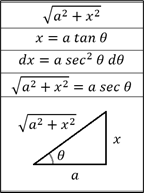

Dado que $v = \tanθ$, la derivada $dv$ con respecto a $θ$ es $\frac{1}{\cos^2θ}$, ya que $\frac{1}{\cos^2θ} = \sec^2θ$. Por lo tanto, $dv = \sec^2θ$. Además, si $\sqrt{a^2 + x^2} = \secθ$, entonces $\sqrt{1 + v^2} = \secθ$.

Ahora sustituimos en la integral
$$\int \frac{1}{secθ} ⋅ sec^2θ$$
\
$$\int secθ dθ$$
\
$$Ln|secθ + tanθ| + C$$
\
Ahora reemplazamos por los valores iniciales.
$$Ln|\sqrt{1 + v^2} + v| + C$$

Como la suma es conmutativo podemos escribir
$$Ln|v + \sqrt{1 + v^2}| + C$$

Ahora simplificamos
$$e^{Ln|v+\sqrt{1+v^2}|} = e^{\frac{-1}{10}Ln|x|+C}$$

$$|v +\sqrt{1+v^2}| = e^{Ln|x|^{\frac{-1}{10}}} \cdot e^c$$

$$|v +\sqrt{1+v^2}| = |x|^{\frac{-1}{10}}\cdot A$$

Como la trayectoria está en el cuadrante 1 podemos eliminar el valor absoluto:

$$v +\sqrt{1+v^2} = x^{\frac{-1}{10}} \cdot A$$


Ahora vamos a realizar el cambio de variable para que la función quede otra vez en términos de $x$ y $y$:

$$\frac{y}{x} + \sqrt{1+(\frac{y}{x})^2} = x^{\frac{-1}{10}}\cdot A$$

$$\frac{y}{x} + \sqrt{1+\frac{y^2}{x^2}} = x^{\frac{-1}{10}}\cdot A$$

$$\frac{y}{x} + \sqrt{\frac{y^2+x^2}{x^2}} = x^{\frac{-1}{10}}\cdot A$$

$$\frac{y}{x} + \frac{\sqrt{y^2+x^2}}{x} = x^{\frac{-1}{10}}\cdot A$$

$$\frac{1}{x}(y+\sqrt{y^2+x^2}) = x^{\frac{-1}{10}}\cdot A$$

$$y+\sqrt{y^2+x^2} = x^{\frac{-1}{10}}\cdot x \cdot A$$

$$y+\sqrt{y^2+x^2} = x^{\frac{9}{10}} \cdot A$$

Despejamos para encontrar la constante

$$A=\frac{y + \sqrt{y^2 + x^2}}{x^\frac{9}{10}}$$

Ahora vamos a evaluar la condicion inicial (200,150)

$$A=\frac{150 + \sqrt{(150)^2 + (200)^2}}{200^\frac{9}{10}}$$

$$A=\frac{150 + \sqrt{22500 + 40000}}{200^\frac{9}{10}}$$

$$A=\frac{150 + \sqrt{62500}}{200^\frac{9}{10}}$$

$$A=\frac{150 + 250}{200^\frac{9}{10}}$$

$$A=\frac{400}{200^\frac{9}{10}}$$

$$A=\frac{2 \cdot 200}{200^\frac{9}{10}}$$

$$A=2 \cdot 200^\frac{1}{10}$$

Ahora agregamos $A$ a la ecuación

$$y + \sqrt{y^2 + x^2} = x^\frac{9}{10} ⋅ 2\cdot 200^\frac{1}{10}$$

$$y + \sqrt{y^2 + x^2} = 2\sqrt[10]{x^9} ⋅ \sqrt[10]{200}$$

$$y + \sqrt{y^2 + x^2} = 2\sqrt[10]{200 \cdot x^9}$$

$$y + \sqrt{y^2 + x^2} = 2(200x^9)^\frac{1}{10}$$




# **Análisis de resultados y conclusiones:**

A partir del análisis numérico y geométrico responda las siguientes preguntas:

**1.** Sin presencia del viento, ¿cual seria el angulo de llegada del avión  respecto al eje x de la trayectoria mas corta, desde el punto de partida hasta el origen de coordenadas

**2.** ¿Que pasa si la velocidad del viento es mayor que la velocidad del avión?¿que pasa si la velocidad del viento es igual a la velocidad del avión?. Realice una gráfica que represente los casos anteriores,

**3.** Si la velocidad del viento es igual a la velocidad del avión. ¿en que punto sobre el eje $y$ deberia estar ubicado el aereopuerto para que el avión lograra aterrizar?  

**4.** Proponga algunas conclusiones. Si para proponer dichas conclusiones debe cambiar hipotesis, no hay problema, solo debe dejar claro que las conclusiones extras estan pensadas para los supuestos planteados por usted.  


- **Velocidades Componentes sin Viento**:
En ausencia de viento, las componentes de velocidad del avión en los ejes $ y $ y $x$ se calculan utilizando las fórmulas:

$$ V_y = \frac{500y}{\sqrt{x^2+y^2}} $$

$$ V_x = \frac{500x}{\sqrt{x^2+y^2}} $$

Esto se debe a que la velocidad total del avión es constante $( 500 \text{ mi/h}) $ y se distribuye entre las componentes horizontal y vertical en función de la posición $(x, y)$ del avión.

- **Cálculo del Ángulo de Llegada**:
Para determinar el ángulo de llegada del avión al aeropuerto, usamos la función tangente ya que tenemos el cateto opuesto $( V_y )$ y el cateto adyacente $( V_x )$. La fórmula es:

$$ \tan(\theta) = \frac{V_y}{V_x} $$

Aplicamos la inversa de la tangente $(tan^{-1})$ para despejar el ángulo $ \theta $:

$$ \theta = \tan^{-1} \left( \frac{V_y}{V_x} \right) $$

Dado que sabemos que $ V_y = \frac{500y}{\sqrt{x^2+y^2}} $ y $ V_x = \frac{500x}{\sqrt{x^2+y^2}} $, los sustituimos en la ecuación:

$$ \theta = \tan^{-1} \left( \frac{\frac{500y}{\sqrt{x^2+y^2}}}{\frac{500x}{\sqrt{x^2+y^2}}} \right) $$

$$ \theta = \tan^{-1} \left( \frac{500y}{\sqrt{x^2+y^2}} \times \frac{\sqrt{x^2+y^2}}{500x} \right) $$

$$ \theta = \tan^{-1} \left( \frac{y}{x} \right) $$

- **Ángulo con Valores Iniciales**:
Dado que las coordenadas iniciales son $ x=200 $ y $ y=150 $, reemplazamos estos valores en la ecuación:

$$ \theta = \tan^{-1} \left( \frac{150}{200} \right) $$

$$ \theta = \tan^{-1}(0.75) $$

$$ \theta \approx 36.8^\circ $$

Por lo tanto, el ángulo de llegada del avión sin la influencia del viento sería aproximadamente $ 36.8^\circ $.


**2.** ¿Que pasa si la velocidad del viento es mayor que la velocidad del avión?¿que pasa si la velocidad del viento es igual a la velocidad del avión?. Realice una gráfica que represente los casos anteriores,

Tenemos el siguiente modelo de ecuación diferencial:

$$ \frac{dy}{dx} = \left( v_0 \cdot \frac{y}{\sqrt{x^2+y^2}} - w \right) \left( \frac{1}{v_0 \cdot \frac{x}{\sqrt{x^2+y^2}}} \right) $$

Para simplificar, pero mantener la forma general de la ecuación, realizamos los siguientes pasos:

1. Primero, multiplicamos los términos dentro de los paréntesis:
   
   $$ \frac{dy}{dx} = \left(\frac{v_0y}{\sqrt{x^2+y^2}} - w \right) \left( \frac{{\sqrt{x^2+y^2}}}{v_0 x} \right) $$

2. Luego, simplificamos cada término:

   $$ \frac{dy}{dx} = \left(\frac{v_0y\sqrt{x^2+y^2}}{v_0x\sqrt{x^2+y^2}}\right) - \left( \frac{{w\sqrt{x^2+y^2}}}{v_0 x} \right) $$

3. Dado que $ \frac{\sqrt{x^2+y^2}}{\sqrt{x^2+y^2}} = 1 $, obtenemos:

   $$ \frac{dy}{dx} = \frac{v_0y}{v_0x} - \frac{w \sqrt{x^2+y^2}}{v_0x} $$

4. Simplificamos aún más para obtener:

   $$ \frac{dy}{dx} = \frac{y}{x} - \frac{w}{v_0} \cdot \frac{\sqrt{x^2+y^2}}{x} $$

Finalmente, después de simplificar, la ecuación diferencial general se convierte en:

$$ \frac{dy}{dx} = \frac{y}{x} - \frac{w}{v_0} \sqrt{1 + \left( \frac{y}{x} \right)^2 } $$

 Lo que nos permite realizar las graficas para los casos sugeridos.








- ¿Que pasa si la velocidad del viento es mayor que la velocidad del avión?

**Respuesta**

Si la velocidad del viento es mayor que la velocidad del avión, la dirección y magnitud del viento dominarán el movimiento del avión. En esta situación, el avión experimentará un arrastre significativo debido al viento, lo que podría hacer que su velocidad relativa con respecto al suelo sea negativa o que su velocidad sea muy baja en comparación con la del viento. Esto podría resultar en que el avión retroceda o avance muy lentamente en comparación con su velocidad habitual.

La gráfica refleja esta situación, donde la velocidad del viento ($w = 800$ supera la velocidad del avión $v_0 = 500$ en el código). En la gráfica, vemos que la trayectoria del avión es influenciada principalmente por el viento, lo que resulta en una curva descendente pronunciada. En términos generales, cuando $w > v_0$, el avión tenderá a ser arrastrado por el viento en lugar de avanzar con su propia potencia.




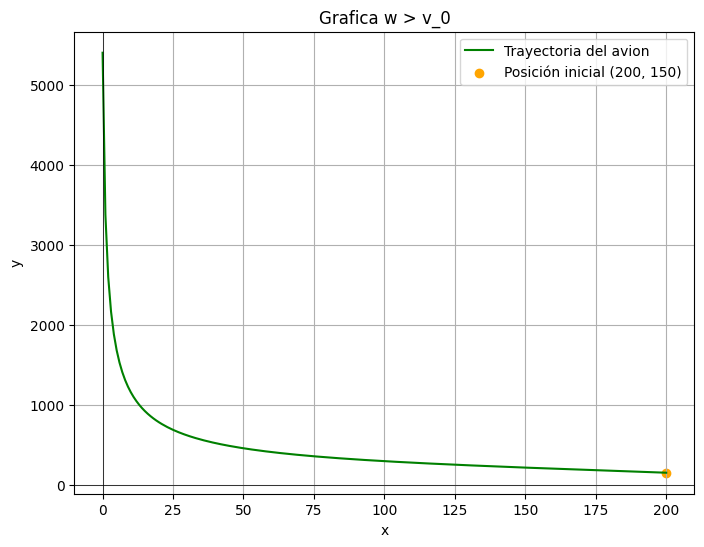

In [ ]:
#Cuando el viento es mayor que la velocidad del avion
def euler(f, y0, x0, xmax, n):
    X = np.linspace(x0, xmax, n+1)
    h = (xmax - x0) / n
    Y = np.zeros_like(X)
    Y[0] = y0
    for i in range(n):
        dy_dx = f(X[i], Y[i])
        Y[i+1] = Y[i] + h * dy_dx
    return X, Y
w = 800
v_0 = 500
# Ecuacion diferencial
def f(x, y):
    return (y/x)-((w/v_0)*(np.sqrt(1 + (y/x)**2)))

# Parámetros iniciales
x0, y0 = 200, 150
xmax = 0
n = 200

# Obtener los valores de X e Y mediante el método de Euler
X, Y = euler(f, y0, x0, xmax, n)

# Graficar la posición del avión y la función proporcionada
plt.figure(figsize=(8, 6))
plt.plot(X, Y, label='Trayectoria del avion ', color='g')
plt.scatter(x0, y0, color='orange', label='Posición inicial (200, 150)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Grafica w > v_0')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True)
plt.show()

¿Que pasa si la velocidad del viento es igual a la velocidad del avión?
Cuando la velocidad del viento es igual a la velocidad del avión se establece un estado de equilibrio relativo en el que la influencia del viento y la velocidad del avión se contrarrestan entre sí. En este caso, la trayectoria del avión está influenciada tanto por su propia velocidad como por la fuerza del viento. Aunque la velocidad del avión y la del viento son iguales en magnitud, la dirección del viento puede desviar ligeramente la trayectoria del avión de su direccion original debido a fluctuaciones en la velocidad del viento o factores atmosféricos variables. Esto puede resultar en una curva suave en la trayectoria del avión, como se observa en la gráfica, donde la trayectoriadel avión se inclina hacia el eje $y$.

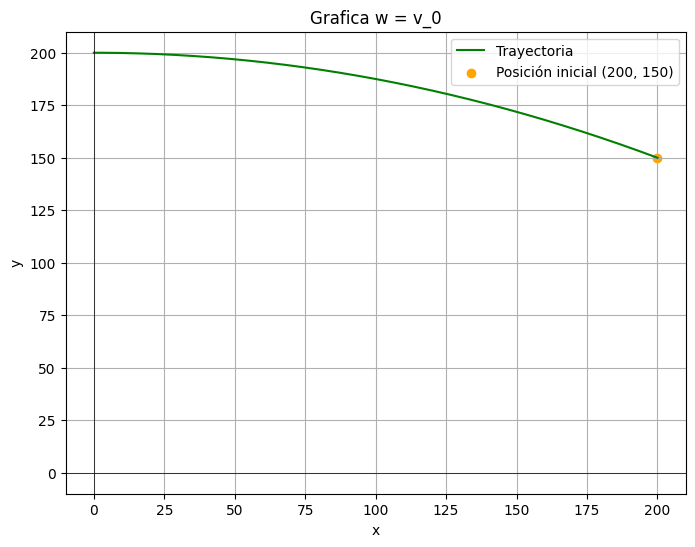

In [ ]:
#Cuando el viento es igual que la velocidad del avion
def euler(f, y0, x0, xmax, n):
    X = np.linspace(x0, xmax, n+1)
    h = (xmax - x0) / n
    Y = np.zeros_like(X)
    Y[0] = y0
    for i in range(n):
        dy_dx = f(X[i], Y[i])
        Y[i+1] = Y[i] + h * dy_dx
    return X, Y
w = 500
v_0 = 500
# Ecuacion diferencial
def f(x, y):
    return (y/x)-((w/v_0)*(np.sqrt(1 + (y/x)**2)))

# Parámetros iniciales
x0, y0 = 200, 150
xmax = 0
n = 2000

# Obtener los valores de X e Y mediante el método de Euler
X, Y = euler(f, y0, x0, xmax, n)

# Graficar la posición del avión y la función proporcionada
plt.figure(figsize=(8, 6))
plt.plot(X, Y, label='Trayectoria', color='g')
plt.scatter(x0, y0, color='orange', label='Posición inicial (200, 150)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Grafica w = v_0')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True)
plt.show()

**3**
Si la velocidad del viento es igual a la velocidad del avión. ¿en que punto sobre el eje $y$ deberia estar ubicado el aereopuerto para que el avión lograra aterrizar?  

**Respuesta**

El avión se dirige hacia el punto $ x = 0 $ y $y = 200$, significa que la componente vertical de la velocidad del avión se equilibra con la velocidad del viento, lo que permite al avión mantenerse estacionario en el eje $ y $. Entonces, el avión podría aterrizar manteniendo una posición fija en el eje $ y $ mientras se desplaza horizontalmente hacia $x = 0 $.Es decir, el aeropuesto debe estar ubicado en el punto $(0,200)$

**4.** Proponga algunas conclusiones. Si para proponer dichas conclusiones debe cambiar hipotesis, no hay problema, solo debe dejar claro que las conclusiones extras estan pensadas para los supuestos planteados por usted.


Del análisis de la ecuación que modela la trayectoria del avión, $ \frac{dy}{dx} - \frac{w}{v_0} \sqrt{1 + \left(\frac{y}{x}\right)^2} $, se obtienen varias conclusiones:

1. **Aletaracion de fuerzas en la trayectoria del avión:** La ecuación describe la relación entre la tasa de cambio de la altitud $\frac{dy}{dx}$ y la relación entre la velocidad vertical y horizontal del avión. Esto indica que la trayectoria del avión está influenciada por factores como la velocidad inicial $v_0$, la relación entre la altitud y la distancia horizontal $\frac{y}{x}$ y la velocidad vertical del viento $w$.

2. **Efecto de la velocidad vertical del viento:** La presencia del término $ \frac{w}{v_0} $,  sugiere que la velocidad vertical del viento afecta la tasa de cambio de la altitud. Si el viento sopla en dirección ascendente $w > 0$, la tasa de cambio de la altitud será mayor, lo que podría favorecer el ascenso del avión. Por el contrario, si el viento sopla en dirección descendente $w < 0$, la tasa de cambio de la altitud disminuirá, lo que podría dificultar el ascenso del avión.

3. **Consideraciones sobre la carga y la resistencia del aire:** Aunque la ecuación no incluye términos explícitos relacionados con la carga del avión o la resistencia del aire, estos factores pueden influir indirectamente en la trayectoria del avión a través de su impacto en la velocidad inicial $v_0$ y la relación entre la altitud y la distancia horizontal $\frac{y}{x}$.
